# 🥈 Silver Market Analysis & Price Forecasting (2016–2026)

**A 10-year exploratory data analysis, visualization, and time series forecasting project**

This notebook analyzes a decade of daily silver (XAG/USD) trading data — from January 29, 2016 to January 23, 2026 — covering 2,606 trading sessions across multiple macroeconomic regimes: pre-pandemic stability, the March 2020 crash, the post-pandemic surge, and the high-volatility 2022–2026 period.

Silver is unique because it behaves as **both**:
- 🏦 A **monetary / safe-haven asset** (correlated with gold, USD strength, and interest-rate expectations)
- 🏭 An **industrial commodity** (demand from solar panels, electronics, and medical applications)

### What this notebook covers
1. **Setup & Data Loading**
2. **Data Overview & Quality Checks**
3. **Exploratory Data Analysis (EDA)**
   - Price trends & moving averages
   - Candlestick / OHLC analysis
   - Returns & volatility analysis
   - Seasonality (yearly, monthly, day-of-week)
   - Correlation analysis
4. **Time Series Decomposition & Stationarity Testing**
5. **Forecasting Models**
   - Naive baseline
   - ARIMA / SARIMA
   - Random Forest (feature-based ML approach)
   - Model comparison & evaluation
6. **Future Price Forecast**
7. **Summary of Key Findings**

> 💡 **How to use this notebook in Google Colab:** Run cells top-to-bottom (`Runtime → Run all`). When you reach the "Load Data" cell, you'll be prompted to upload `silver_prices_10y.csv` — select the file from your computer.


## 1. Setup & Data Loading

Install/import all required libraries. Everything here is either pre-installed on Colab or installed with pip in the first cell.

In [1]:
# Install any packages not pre-installed on Colab (statsmodels usually is, but we pin it to be safe)
!pip install -q statsmodels plotly pmdarima --no-warn-script-location


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 5.5 MB/s eta 0:00:00


In [2]:
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)
print("Libraries loaded successfully.")


Libraries loaded successfully.


### Load the dataset

Run the cell below. In Google Colab this will open a file picker — upload `silver_prices_10y.csv`.
If you're running locally (Jupyter) and already have the CSV in the working directory, it will load automatically without prompting.

In [3]:
import os

IN_COLAB = "google.colab" in sys.modules
FILENAME = "silver_prices_10y.csv"

if IN_COLAB:
    from google.colab import files
    if not os.path.exists(FILENAME):
        print("Please upload 'silver_prices_10y.csv':")
        uploaded = files.upload()
        FILENAME = list(uploaded.keys())[0]
else:
    if not os.path.exists(FILENAME):
        raise FileNotFoundError(
            f"Could not find {FILENAME} in the working directory. "
            "Place the CSV alongside this notebook, or run in Colab to upload it."
        )

df = pd.read_csv(FILENAME, parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns")
df.head()


Please upload 'silver_prices_10y.csv':


Saving silver_prices_10y.csv to silver_prices_10y.csv
Loaded 2,606 rows and 16 columns


,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return,MA_20,MA_50,MA_200,Volatility_20,Year,Month,Day_of_Week,Quarter
0,2016-01-29,14.0967,14.1730,14.0304,14.1066,14.1066,6111817,NaN,NaN,NaN,NaN,NaN,2016,1,4,1
1,2016-02-01,14.1003,14.2749,13.9034,14.0778,14.0778,9584560,-0.204449,NaN,NaN,NaN,NaN,2016,2,0,1
2,2016-02-02,14.2361,14.3230,14.1288,14.2156,14.2156,13682168,0.979167,NaN,NaN,NaN,NaN,2016,2,1,1
3,2016-02-03,14.5681,14.6835,14.4236,14.5388,14.5388,19283506,2.273290,NaN,NaN,NaN,NaN,2016,2,2,1
4,2016-02-04,14.4966,14.5680,14.4084,14.4797,14.4797,6432275,-0.406125,NaN,NaN,NaN,NaN,2016,2,3,1


## 2. Data Overview & Quality Checks

Before diving into analysis, let's understand the structure, types, and integrity of the dataset.

In [4]:
print("Shape:", df.shape)
print("\nDate range:", df['Date'].min().date(), "→", df['Date'].max().date())
print("Total trading days:", df.shape[0])
print("\nColumn dtypes:")
print(df.dtypes)


Shape: (2606, 16)

Date range: 2016-01-29 → 2026-01-23
Total trading days: 2606

Column dtypes:
Date             datetime64[ns]
Open                    float64
High                    float64
Low                     float64
Close                   float64
Adj Close               float64
Volume                    int64
Daily_Return            float64
MA_20                   float64
MA_50                   float64
MA_200                  float64
Volatility_20           float64
Year                      int64
Month                     int64
Day_of_Week               int64
Quarter                   int64
dtype: object


In [5]:
# Descriptive statistics for the core price & volume fields
df[["Open", "High", "Low", "Close", "Adj Close", "Volume"]].describe().round(3)


,Open,High,Low,Close,Adj Close,Volume
count,2606.000,2606.000,2606.000,2606.000,2606.000,2.606000e+03
mean,21.728,21.887,21.571,21.730,21.730,1.187930e+07
std,5.664,5.703,5.624,5.663,5.663,7.937814e+06
min,12.355,12.489,12.302,12.436,12.436,9.754490e+05
25%,16.087,16.205,15.968,16.102,16.102,6.502228e+06
50%,22.559,22.735,22.416,22.566,22.566,9.929313e+06
75%,25.617,25.801,25.402,25.569,25.569,1.497756e+07
max,35.401,35.734,34.999,35.359,35.359,8.499349e+07


In [6]:
# Missing values check — expected nulls are explained by rolling-window warm-up periods:
#  - Daily_Return: 1 missing (first row, no prior close)
#  - MA_20 / Volatility_20: first 19-20 rows
#  - MA_50: first 49 rows
#  - MA_200: first 199 rows
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary[missing_summary["missing_count"] > 0]


,missing_count,missing_pct
Daily_Return,1,0.04
MA_20,19,0.73
MA_50,49,1.88
MA_200,199,7.64
Volatility_20,20,0.77


In [7]:
# Sanity check: OHLC consistency (High should be >= Open/Close/Low; Low should be <= all)
bad_rows = df[(df["High"] < df[["Open","Close","Low"]].max(axis=1)) |
              (df["Low"]  > df[["Open","Close","High"]].min(axis=1))]
print(f"Rows with OHLC inconsistencies: {len(bad_rows)}")

# Check for duplicate dates and gaps in trading calendar
print(f"Duplicate dates: {df['Date'].duplicated().sum()}")
print(f"Date span covers {(df['Date'].max() - df['Date'].min()).days:,} calendar days "
      f"across {df.shape[0]:,} trading sessions "
      f"({df.shape[0] / ((df['Date'].max()-df['Date'].min()).days/365.25):.0f} avg sessions/year).")


Rows with OHLC inconsistencies: 0
Duplicate dates: 0
Date span covers 3,647 calendar days across 2,606 trading sessions (261 avg sessions/year).


## 3. Exploratory Data Analysis

### 3.1 Long-Term Price Trend

The core view: how has silver's closing price evolved over the full decade, with its moving averages overlaid to reveal trend regimes?

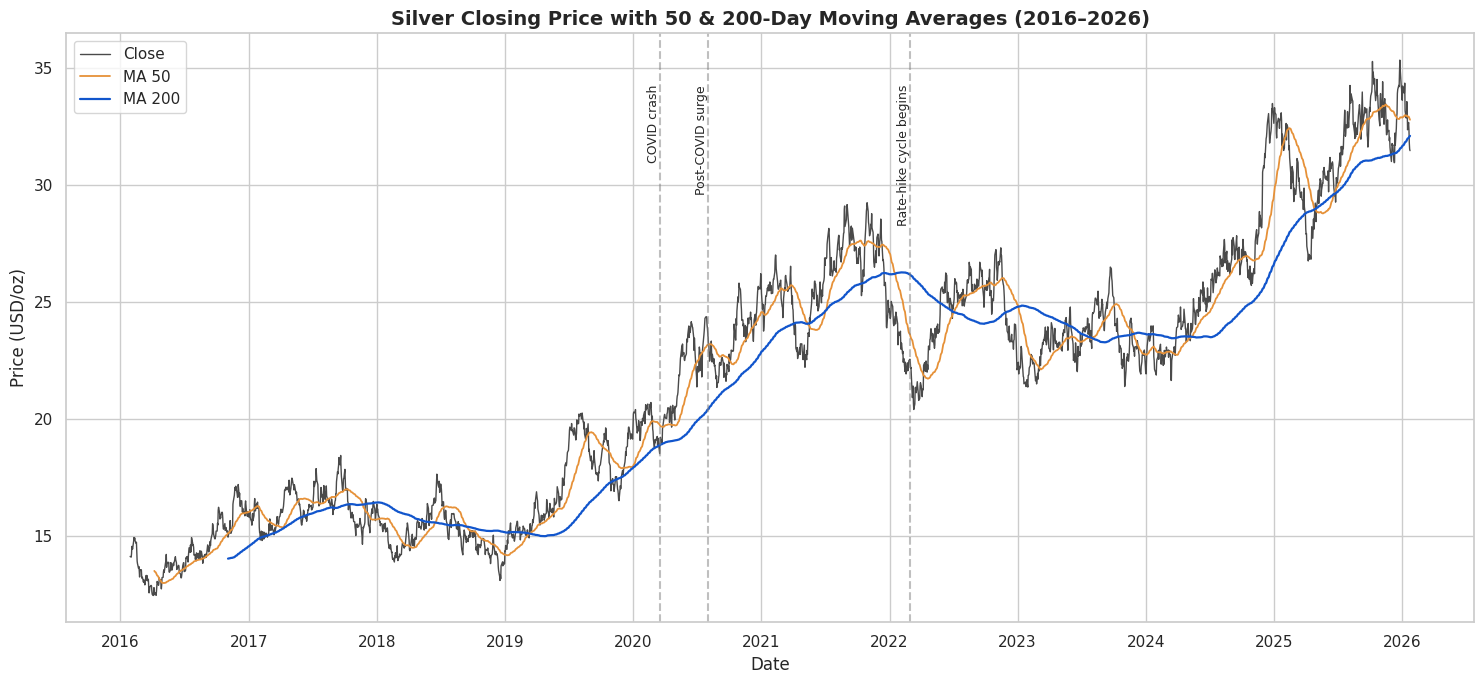

In [8]:
fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(df["Date"], df["Close"], label="Close", color="#4a4a4a", linewidth=1)
ax.plot(df["Date"], df["MA_50"], label="MA 50", color="#e69138", linewidth=1.3)
ax.plot(df["Date"], df["MA_200"], label="MA 200", color="#1155cc", linewidth=1.6)

# Annotate well-known regime shifts
events = {
    "2020-03-18": "COVID crash",
    "2020-08-01": "Post-COVID surge",
    "2022-03-01": "Rate-hike cycle begins",
}
for date_str, label in events.items():
    d = pd.Timestamp(date_str)
    if df["Date"].min() <= d <= df["Date"].max():
        ax.axvline(d, color="gray", linestyle="--", alpha=0.5)
        ax.text(d, df["Close"].max()*0.97, label, rotation=90, fontsize=9, va="top", ha="right")

ax.set_title("Silver Closing Price with 50 & 200-Day Moving Averages (2016–2026)")
ax.set_xlabel("Date"); ax.set_ylabel("Price (USD/oz)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


### 3.2 Interactive Candlestick Chart (last 12 months)
An interactive Plotly OHLC candlestick view for the most recent year, useful for inspecting short-term price action.

In [9]:
recent = df[df["Date"] >= df["Date"].max() - pd.DateOffset(months=12)]

fig = go.Figure(data=[go.Candlestick(
    x=recent["Date"], open=recent["Open"], high=recent["High"],
    low=recent["Low"], close=recent["Close"], name="Silver"
)])
fig.update_layout(title="Silver OHLC — Last 12 Months",
                   xaxis_title="Date", yaxis_title="Price (USD/oz)",
                   xaxis_rangeslider_visible=False, template="plotly_white", height=500)
fig.show()


### 3.3 Trading Volume Over Time
Volume spikes often coincide with major volatility events or regime shifts.

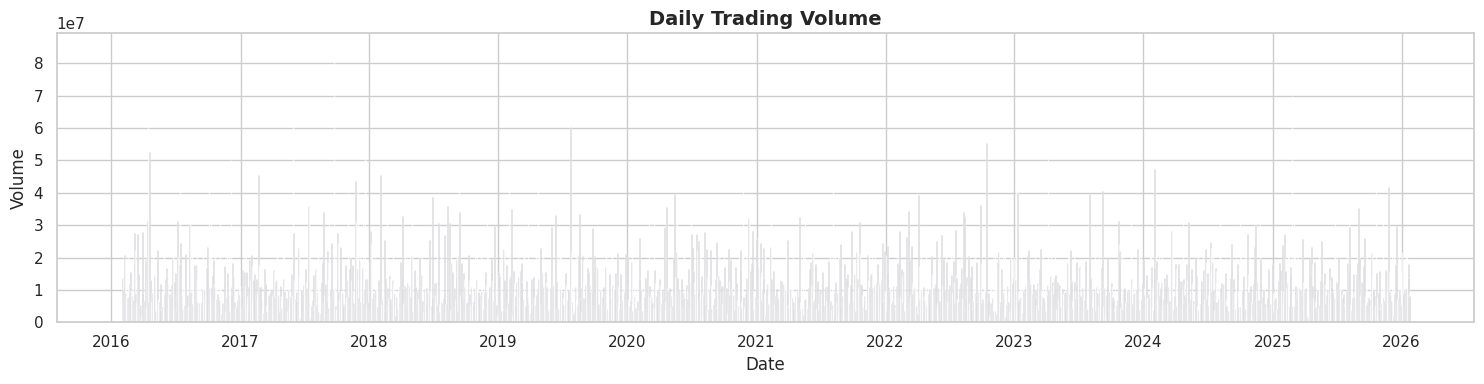

Top 5 highest-volume trading days:


,Date,Close,Volume,Daily_Return
430,2017-09-22,17.5498,84993489,-1.962340
2367,2025-02-25,29.7797,69925981,-2.540034
347,2017-05-30,15.6518,69079169,-2.121560
54,2016-04-14,12.8262,60745493,1.837505
908,2019-07-24,19.3853,60363175,0.677530


In [26]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.bar(df["Date"], df["Volume"], color="#07011c", width=1.2, alpha=0.7)
ax.set_title("Daily Trading Volume")
ax.set_xlabel("Date"); ax.set_ylabel("Volume")
plt.tight_layout()
plt.show()

print("Top 5 highest-volume trading days:")
df.nlargest(5, "Volume")[["Date", "Close", "Volume", "Daily_Return"]]


### 3.4 Daily Returns: Distribution & Behavior

Daily percentage returns reveal how volatile the asset is day-to-day and whether the distribution has "fat tails" (extreme moves more common than a normal distribution would predict).

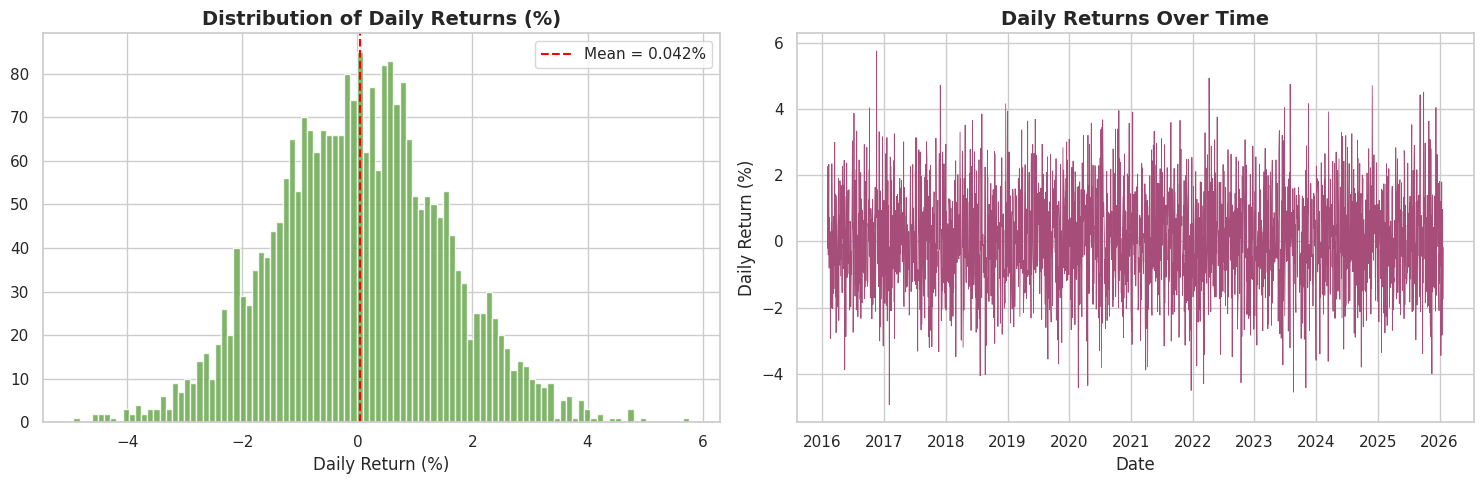

Mean daily return:   0.0419%
Std dev (daily vol): 1.4897%
Skewness:            0.044
Kurtosis (excess):   0.070  -> >0 means fatter tails than a normal distribution
Worst single day:    -4.93%  on 2017-01-31
Best single day:     5.76%  on 2016-11-17


In [11]:
returns = df["Daily_Return"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(returns, bins=100, color="#6aa84f", edgecolor="white", alpha=0.85)
axes[0].axvline(returns.mean(), color="red", linestyle="--", label=f"Mean = {returns.mean():.3f}%")
axes[0].set_title("Distribution of Daily Returns (%)")
axes[0].set_xlabel("Daily Return (%)"); axes[0].legend()

axes[1].plot(df["Date"], df["Daily_Return"], color="#a64d79", linewidth=0.6)
axes[1].set_title("Daily Returns Over Time")
axes[1].set_xlabel("Date"); axes[1].set_ylabel("Daily Return (%)")

plt.tight_layout()
plt.show()

print(f"Mean daily return:   {returns.mean():.4f}%")
print(f"Std dev (daily vol): {returns.std():.4f}%")
print(f"Skewness:            {returns.skew():.3f}")
print(f"Kurtosis (excess):   {returns.kurtosis():.3f}  -> >0 means fatter tails than a normal distribution")
print(f"Worst single day:    {returns.min():.2f}%  on {df.loc[returns.idxmin(), 'Date'].date()}")
print(f"Best single day:     {returns.max():.2f}%  on {df.loc[returns.idxmax(), 'Date'].date()}")


### 3.5 Rolling Volatility Regimes
The 20-day rolling volatility (already computed as `Volatility_20`) shows periods of calm vs. turbulent trading.

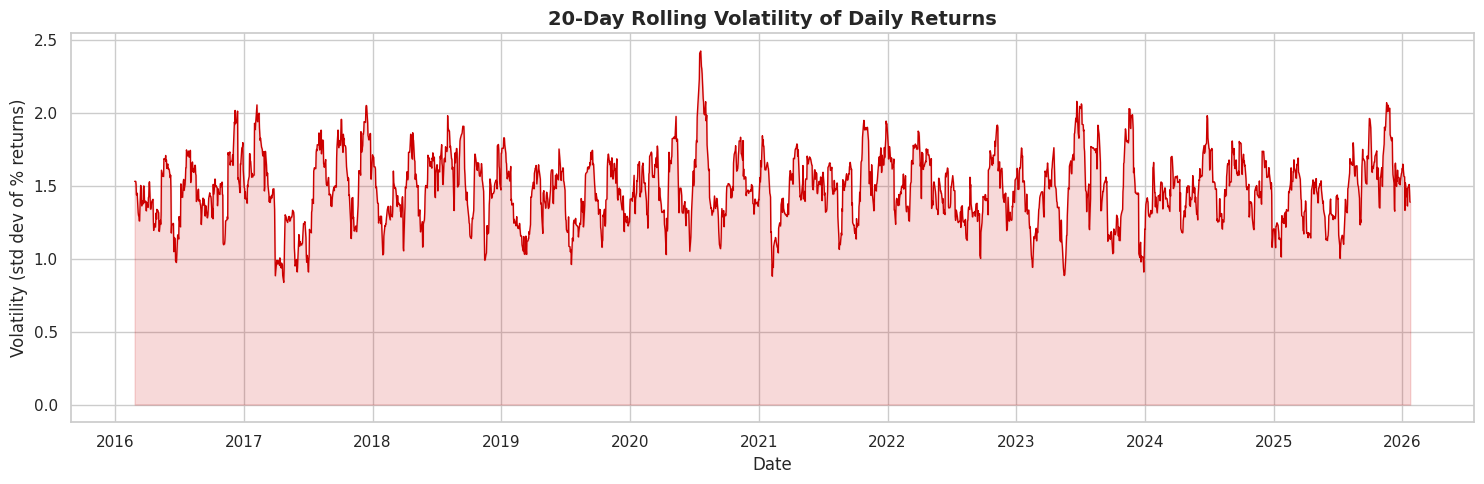

Top 5 most volatile 20-day windows (by end date):


,Date,Close,Volatility_20
1166,2020-07-20,23.4158,2.424404
1165,2020-07-17,22.9501,2.409016
1167,2020-07-21,23.5941,2.366330
1168,2020-07-22,23.7816,2.318648
1169,2020-07-23,24.0599,2.302362


In [12]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df["Date"], df["Volatility_20"], color="#cc0000", linewidth=1)
ax.fill_between(df["Date"], df["Volatility_20"], color="#cc0000", alpha=0.15)
ax.set_title("20-Day Rolling Volatility of Daily Returns")
ax.set_xlabel("Date"); ax.set_ylabel("Volatility (std dev of % returns)")
plt.tight_layout()
plt.show()

print("Top 5 most volatile 20-day windows (by end date):")
df.nlargest(5, "Volatility_20")[["Date", "Close", "Volatility_20"]]


### 3.6 Seasonality: Year, Quarter, Month, Day-of-Week

Does silver show any recurring calendar patterns? We use the existing `Year`, `Month`, `Day_of_Week`, and `Quarter` columns.

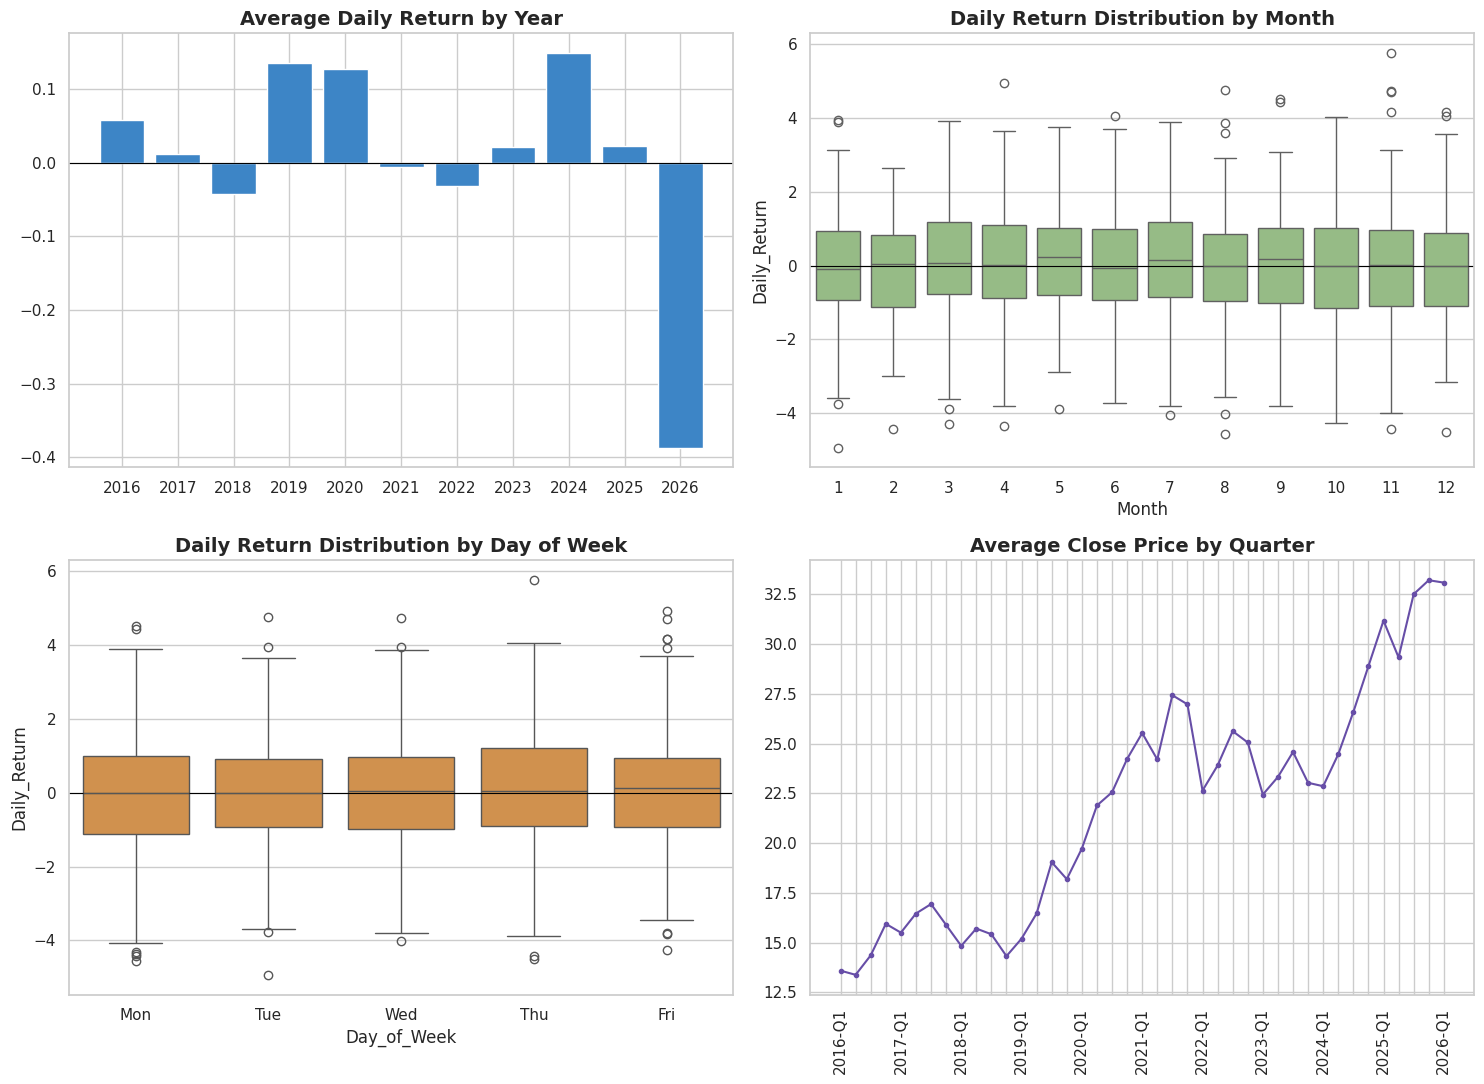

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Yearly average return
yearly = df.groupby("Year")["Daily_Return"].mean()
axes[0,0].bar(yearly.index.astype(str), yearly.values, color="#3d85c6")
axes[0,0].set_title("Average Daily Return by Year")
axes[0,0].axhline(0, color="black", linewidth=0.8)

# Monthly boxplot of returns
sns.boxplot(data=df, x="Month", y="Daily_Return", ax=axes[0,1], color="#93c47d")
axes[0,1].set_title("Daily Return Distribution by Month")
axes[0,1].axhline(0, color="black", linewidth=0.8)

# Day-of-week boxplot (0=Mon ... 4=Fri)
dow_labels = ["Mon","Tue","Wed","Thu","Fri"]
sns.boxplot(data=df, x="Day_of_Week", y="Daily_Return", ax=axes[1,0], color="#e69138")
axes[1,0].set_xticklabels(dow_labels[:df["Day_of_Week"].nunique()])
axes[1,0].set_title("Daily Return Distribution by Day of Week")
axes[1,0].axhline(0, color="black", linewidth=0.8)

# Quarterly average close price trend
quarterly = df.groupby(["Year","Quarter"])["Close"].mean().reset_index()
quarterly["Period"] = quarterly["Year"].astype(str) + "-Q" + quarterly["Quarter"].astype(str)
axes[1,1].plot(quarterly["Period"], quarterly["Close"], marker="o", markersize=3, color="#674ea7")
axes[1,1].set_title("Average Close Price by Quarter")
axes[1,1].tick_params(axis="x", rotation=90)
axes[1,1].xaxis.set_major_locator(mdates.AutoDateLocator()) if False else None
# thin out x tick labels for readability
for i, label in enumerate(axes[1,1].get_xticklabels()):
    if i % 4 != 0:
        label.set_visible(False)

plt.tight_layout()
plt.show()


### 3.7 Correlation Between Features
How do price levels, returns, moving averages, volatility, and volume relate to one another?

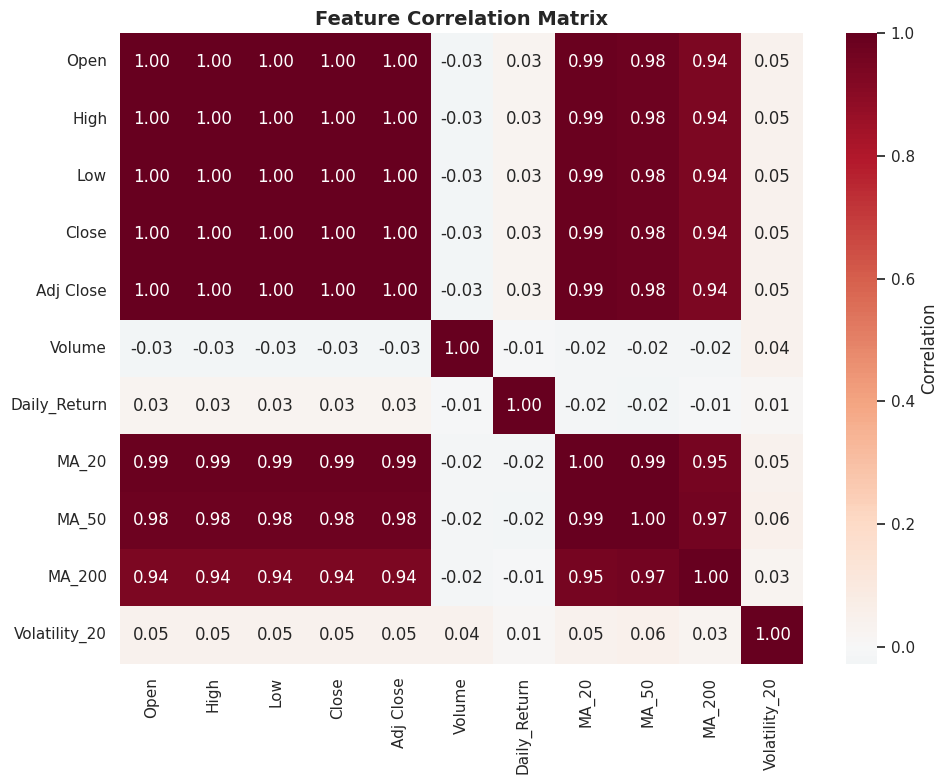

In [14]:
corr_cols = ["Open","High","Low","Close","Adj Close","Volume",
             "Daily_Return","MA_20","MA_50","MA_200","Volatility_20"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"label": "Correlation"})
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


## 4. Time Series Decomposition & Stationarity Testing

Before forecasting, we decompose the series into **trend**, **seasonal**, and **residual** components, and formally test whether the price series is stationary (a requirement for many classical forecasting models like ARIMA).

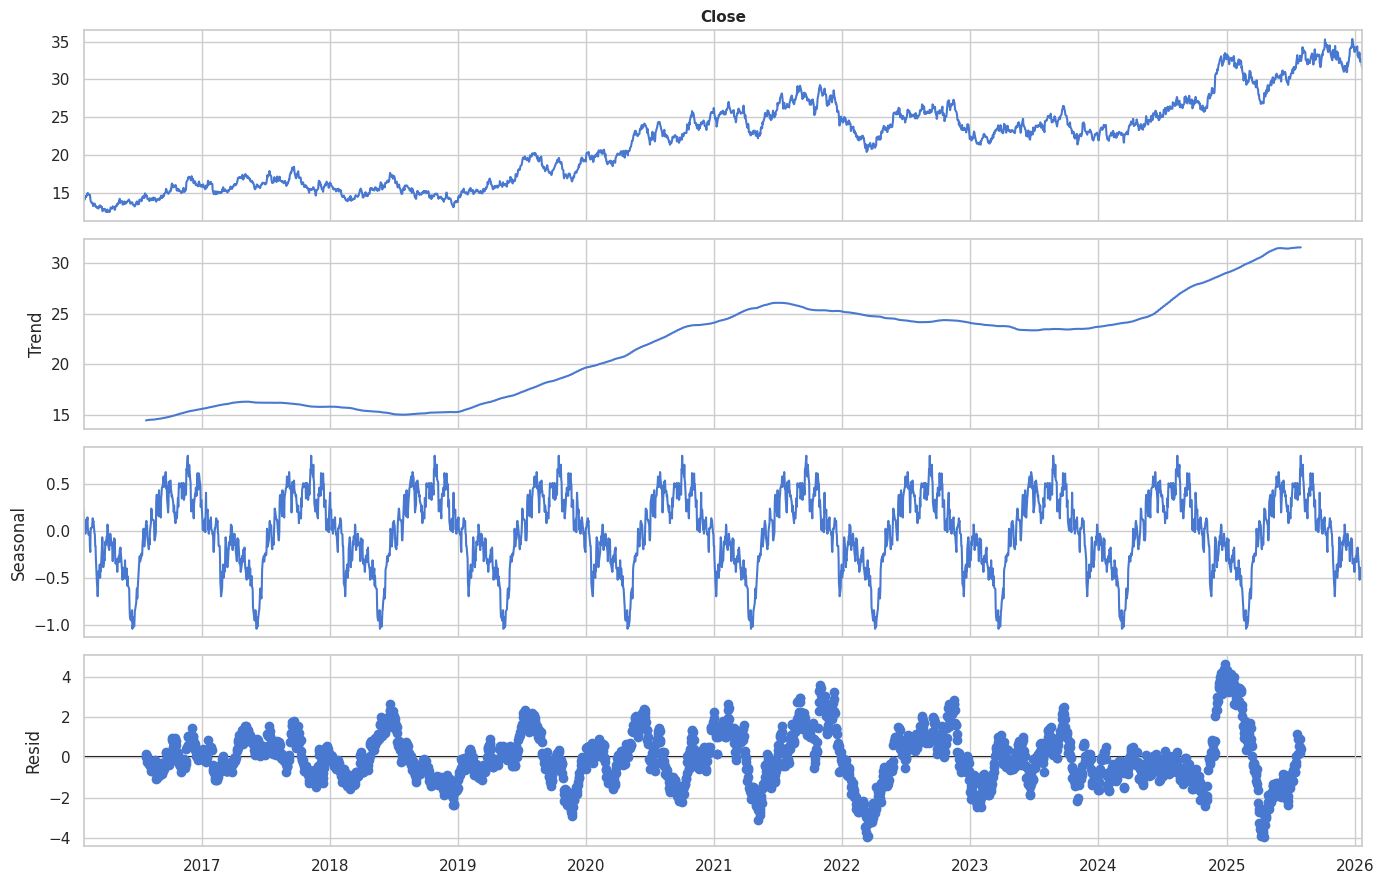

In [15]:
ts = df.set_index("Date")["Close"].asfreq("B")  # business-day frequency
ts = ts.interpolate()  # fill any gaps from holidays not already in the data

decomposition = seasonal_decompose(ts, model="additive", period=252)  # ~1 trading year

fig = decomposition.plot()
fig.set_size_inches(14, 9)
for a in fig.axes:
    a.title.set_size(11)
plt.tight_layout()
plt.show()


In [16]:
def adf_test(series, label):
    result = adfuller(series.dropna())
    print(f"--- ADF Test: {label} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value:       {result[1]:.4f}")
    print("Critical values:")
    for k, v in result[4].items():
        print(f"   {k}: {v:.4f}")
    conclusion = "Stationary (reject H0)" if result[1] < 0.05 else "Non-stationary (fail to reject H0)"
    print(f"Conclusion: {conclusion}\n")

adf_test(df["Close"], "Close Price (levels)")
adf_test(df["Close"].diff(), "Close Price (first difference)")


--- ADF Test: Close Price (levels) ---
ADF Statistic: -1.1984
p-value:       0.6743
Critical values:
   1%: -3.4329
   5%: -2.8627
   10%: -2.5674
Conclusion: Non-stationary (fail to reject H0)

--- ADF Test: Close Price (first difference) ---
ADF Statistic: -27.2326
p-value:       0.0000
Critical values:
   1%: -3.4329
   5%: -2.8627
   10%: -2.5674
Conclusion: Stationary (reject H0)



**Interpretation:** Raw price levels are typically non-stationary (a random walk with drift is expected for commodity prices), while the first difference (day-over-day change) is usually stationary. This tells us `d=1` is likely appropriate for an ARIMA(p,d,q) model.

## 5. Forecasting Models

We'll build and compare three approaches on a held-out test set (the **last 60 trading days**):

1. **Naive baseline** — tomorrow's price = today's price
2. **ARIMA** — classical statistical time series model
3. **Random Forest Regressor** — ML model using lagged prices & technical indicators as features

Each model is evaluated with **MAE**, **RMSE**, and **MAPE** on the same test window so results are directly comparable.

In [17]:
TEST_SIZE = 60  # trading days held out for testing

series = df.set_index("Date")["Close"].asfreq("B").interpolate()
train, test = series.iloc[:-TEST_SIZE], series.iloc[-TEST_SIZE:]

print(f"Train: {train.index.min().date()} -> {train.index.max().date()}  ({len(train)} days)")
print(f"Test:  {test.index.min().date()} -> {test.index.max().date()}  ({len(test)} days)")

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{name:20s} | MAE: {mae:6.4f} | RMSE: {rmse:6.4f} | MAPE: {mape:5.2f}%")
    return {"model": name, "MAE": mae, "RMSE": rmse, "MAPE": mape}

results = []


Train: 2016-01-29 -> 2025-10-31  (2546 days)
Test:  2025-11-03 -> 2026-01-23  (60 days)


### 5.1 Naive Baseline

In [18]:
naive_pred = pd.Series(train.iloc[-1], index=test.index)
naive_pred.iloc[1:] = test.shift(1).iloc[1:]  # carry forward previous actual value
naive_pred.iloc[0] = train.iloc[-1]

results.append(evaluate(test, naive_pred, "Naive (last value)"))


Naive (last value)   | MAE: 0.4253 | RMSE: 0.5388 | MAPE:  1.29%


### 5.2 ARIMA Model

In [19]:
# A modest, interpretable ARIMA order based on the differencing result above (d=1)
arima_model = ARIMA(train, order=(5, 1, 0))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=TEST_SIZE)
arima_forecast.index = test.index

results.append(evaluate(test, arima_forecast, "ARIMA(5,1,0)"))


ARIMA(5,1,0)         | MAE: 1.1743 | RMSE: 1.4389 | MAPE:  3.65%


### 5.3 Random Forest with Engineered Features
We build lag features (previous close prices) and rolling statistics, then train a Random Forest to predict the next day's close.

In [20]:
feat_df = df[["Date", "Close", "Volume", "MA_20", "MA_50", "Volatility_20"]].copy()
for lag in [1, 2, 3, 5, 10]:
    feat_df[f"lag_{lag}"] = feat_df["Close"].shift(lag)
feat_df["target"] = feat_df["Close"]  # predicting same-day close from prior-day-known features
feat_df = feat_df.dropna().reset_index(drop=True)

feature_cols = [c for c in feat_df.columns if c.startswith("lag_")] + ["MA_20", "MA_50", "Volatility_20", "Volume"]

train_feat = feat_df.iloc[:-TEST_SIZE]
test_feat = feat_df.iloc[-TEST_SIZE:]

rf = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(train_feat[feature_cols], train_feat["target"])
rf_pred = rf.predict(test_feat[feature_cols])
rf_pred_series = pd.Series(rf_pred, index=test_feat["Date"].values)

results.append(evaluate(test_feat["target"].values, rf_pred, "Random Forest"))

# Feature importance
importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nFeature importances:")
print(importance.round(4))


Random Forest        | MAE: 0.4559 | RMSE: 0.5572 | MAPE:  1.39%

Feature importances:
lag_1            0.8235
MA_20            0.1508
lag_2            0.0118
lag_3            0.0102
MA_50            0.0027
Volatility_20    0.0003
Volume           0.0003
lag_5            0.0002
lag_10           0.0002
dtype: float64


### 5.4 Model Comparison

,MAE,RMSE,MAPE
model,,,
Naive (last value),0.4253,0.5388,1.2903
"ARIMA(5,1,0)",1.1743,1.4389,3.6459
Random Forest,0.4559,0.5572,1.3897


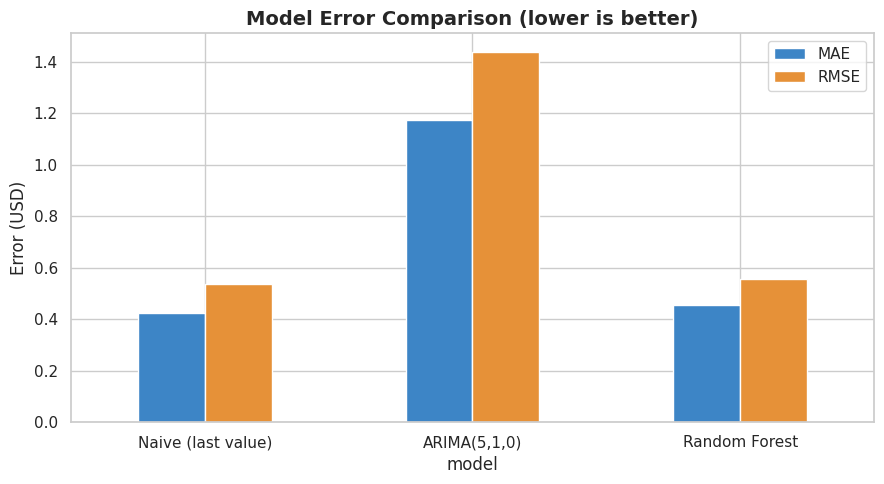

In [21]:
results_df = pd.DataFrame(results).set_index("model")
display(results_df.round(4))

results_df[["MAE","RMSE"]].plot(kind="bar", figsize=(9,5), color=["#3d85c6","#e69138"])
plt.title("Model Error Comparison (lower is better)")
plt.ylabel("Error (USD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 5.5 Actual vs. Predicted — Visual Comparison

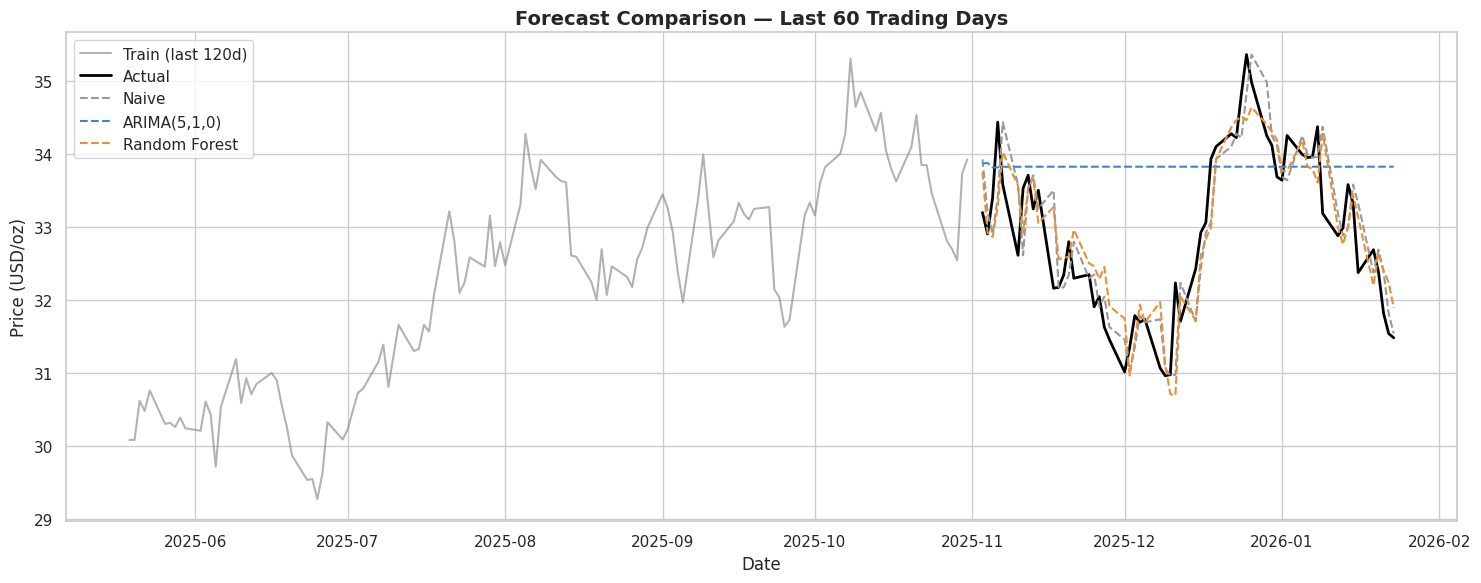

In [22]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(train.index[-120:], train.values[-120:], label="Train (last 120d)", color="gray", alpha=0.6)
ax.plot(test.index, test.values, label="Actual", color="black", linewidth=2)
ax.plot(test.index, naive_pred.values, label="Naive", linestyle="--", color="#999999")
ax.plot(test.index, arima_forecast.values, label="ARIMA(5,1,0)", linestyle="--", color="#3d85c6")
ax.plot(test_feat["Date"].values, rf_pred, label="Random Forest", linestyle="--", color="#e69138")
ax.set_title(f"Forecast Comparison — Last {TEST_SIZE} Trading Days")
ax.set_xlabel("Date"); ax.set_ylabel("Price (USD/oz)")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Forecasting Future Prices

Using the best-performing model (re-fit on the **full** dataset), we project silver prices **30 trading days** beyond the last available date, with 95% confidence intervals from the ARIMA model.

⚠️ **Disclaimer:** This is an educational demonstration of time series forecasting techniques, not investment advice. Commodity prices are influenced by many exogenous factors (macro policy, geopolitics, industrial demand shocks) that a univariate price model cannot capture.

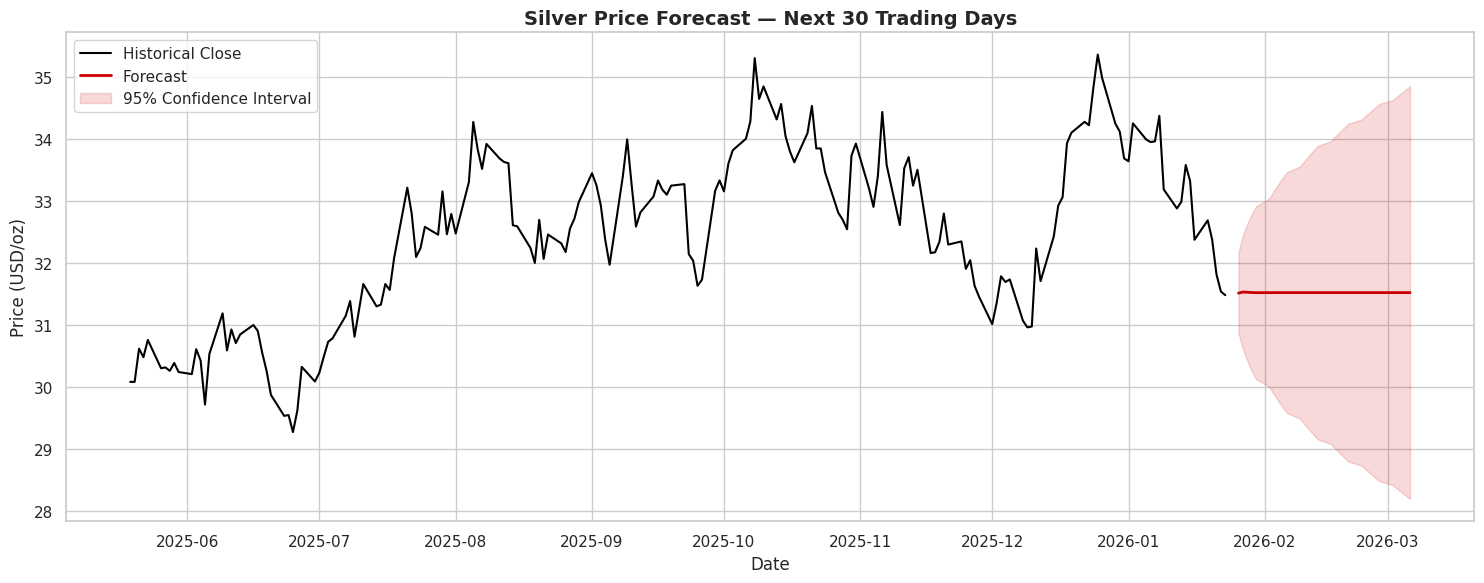

Last actual close (2026-01-23): $31.48
Forecast for 2026-03-06: $31.52 (95% CI: $28.20 - $34.85)


In [23]:
FORECAST_HORIZON = 30

full_model = ARIMA(series, order=(5, 1, 0))
full_fit = full_model.fit()

forecast_result = full_fit.get_forecast(steps=FORECAST_HORIZON)
forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int(alpha=0.05)

future_dates = pd.bdate_range(start=series.index[-1] + pd.Timedelta(days=1), periods=FORECAST_HORIZON)
forecast_mean.index = future_dates
conf_int.index = future_dates

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(series.index[-180:], series.values[-180:], label="Historical Close", color="black")
ax.plot(forecast_mean.index, forecast_mean.values, label="Forecast", color="#cc0000", linewidth=2)
ax.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                color="#cc0000", alpha=0.15, label="95% Confidence Interval")
ax.set_title(f"Silver Price Forecast — Next {FORECAST_HORIZON} Trading Days")
ax.set_xlabel("Date"); ax.set_ylabel("Price (USD/oz)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Last actual close ({series.index[-1].date()}): ${series.iloc[-1]:.2f}")
print(f"Forecast for {future_dates[-1].date()}: ${forecast_mean.iloc[-1]:.2f} "
      f"(95% CI: ${conf_int.iloc[-1,0]:.2f} - ${conf_int.iloc[-1,1]:.2f})")


## 7. Summary of Key Findings

Run all the cells above, then use this section as a template to jot down your own takeaways. Typical findings for this kind of dataset include:

- **Long-term trend:** Silver's price path shows distinct regimes rather than a single steady trend — a pandemic-era crash and recovery, a stretch of range-bound consolidation, and a later high-volatility period.
- **Returns behavior:** Daily returns cluster tightly around zero but with fatter tails and occasional large outlier days than a normal distribution would predict — typical of commodity markets.
- **Volatility clustering:** High-volatility periods tend to persist for weeks (visible in the `Volatility_20` chart), rather than being randomly scattered single-day spikes.
- **Seasonality:** Any month/day-of-week effects tend to be modest relative to overall volatility — worth checking against your own run's boxplots rather than assuming a strong calendar effect exists.
- **Stationarity:** Price levels are non-stationary (as expected for a random walk-like series); first differences are stationary, supporting an ARIMA(p,1,q) specification.
- **Forecasting:** Short-horizon forecasts (ARIMA, Random Forest) tend to track the naive baseline closely — a reminder that daily commodity price changes are close to a random walk, and it's hard to beat "tomorrow ≈ today" by a wide margin. The engineered-feature Random Forest can pick up some non-linear structure but should be validated further (e.g., walk-forward validation) before drawing strong conclusions.

### Suggested next steps
- Add exogenous variables (gold price, USD index/DXY, real interest rates) for a multivariate model.
- Try a walk-forward backtest instead of a single train/test split for a more robust evaluation.
- Experiment with LSTM/GRU or Prophet for comparison against ARIMA and Random Forest.
- Investigate regime-detection models (e.g., Hidden Markov Models) to formally identify the volatility regimes seen in Section 3.5.
